In [1]:
%load_ext autotime

import scarf
scarf.__version__

'1.0.0'

time: 1.1 s (started: 2026-06-28 22:59:31 +02:00)


In [2]:
scarf.fetch_dataset(
    'tenx_8K_pbmc_citeseq',
    save_path='scarf_datasets'
)

time: 17.3 s (started: 2026-06-28 22:59:32 +02:00)


In [3]:
reader = scarf.CrH5Reader(
    'scarf_datasets/tenx_8K_pbmc_citeseq/data.h5'
)

time: 13 ms (started: 2026-06-28 22:59:49 +02:00)


In [4]:
reader.assayFeats

,RNA,ADT
type,Gene Expression,Antibody Capture
start,0,33538
end,33538,33555
nFeatures,33538,17


time: 5.58 ms (started: 2026-06-28 22:59:49 +02:00)


In [5]:
reader.rename_assays({'assay2': 'ADT'})
reader.assayFeats

,RNA,ADT
type,Gene Expression,Antibody Capture
start,0,33538
end,33538,33555
nFeatures,33538,17


time: 3.24 ms (started: 2026-06-28 22:59:49 +02:00)


In [6]:
writer = scarf.CrToZarr(
    reader,
    zarr_loc='scarf_datasets/tenx_8K_pbmc_citeseq/data.zarr',
    chunk_size=(2000, 1000),
)
writer.dump(batch_size=1000)

  0%|                                                                                                         …

time: 7.16 s (started: 2026-06-28 22:59:49 +02:00)


In [7]:
ds = scarf.DataStore(
    'scarf_datasets/tenx_8K_pbmc_citeseq/data.zarr',
    default_assay='RNA',
    nthreads=4
)

(RNA) Computing nCells and dropOuts:   0%|                                                                    …

(ADT) Computing nCells and dropOuts:   0%|                                                                    …

(ADT) Computing nCounts:   0%|                                                                                …

(ADT) Computing nFeatures:   0%|                                                                              …

(RNA) Computing nCounts:   0%|                                                                                …

(RNA) Computing nFeatures:   0%|                                                                              …

(RNA) Computing RNA_percentMito:   0%|                                                                        …

(RNA) Computing RNA_percentRibo:   0%|                                                                        …

time: 6.54 s (started: 2026-06-28 22:59:56 +02:00)


In [8]:
ds

DataStore has 7865 (7865) cells with 2 assays: RNA ADT
   Cell metadata:
            'I', 'ids', 'names', 'RNA_nCounts', 'ADT_nFeatures', 
            'RNA_percentMito', 'RNA_nFeatures', 'RNA_percentRibo', 'ADT_nCounts'
   ADT assay has 17 (17) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          
   RNA assay has 13832 (33538) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          

time: 65.8 ms (started: 2026-06-28 23:00:02 +02:00)


In [9]:
ds.RNA.feats.head()

,I,ids,names,nCells,dropOuts
0,False,ENSG00000243485,MIR1302-2HG,0,7865
1,False,ENSG00000237613,FAM138A,0,7865
2,False,ENSG00000186092,OR4F5,0,7865
3,False,ENSG00000238009,AL627309.1,12,7853
4,False,ENSG00000239945,AL627309.3,0,7865


time: 42.7 ms (started: 2026-06-28 23:00:02 +02:00)


In [10]:
ds.ADT.feats.head()

,I,ids,names,nCells,dropOuts
0,True,CD3,CD3_TotalSeqB,7864,1
1,True,CD4,CD4_TotalSeqB,7864,1
2,True,CD8a,CD8a_TotalSeqB,7863,2
3,True,CD14,CD14_TotalSeqB,7864,1
4,True,CD15,CD15_TotalSeqB,7864,1


time: 38 ms (started: 2026-06-28 23:00:03 +02:00)


INFO: 154 cells flagged for filtering out using attribute RNA_nCounts


INFO: 326 cells flagged for filtering out using attribute RNA_nFeatures


INFO: 119 cells flagged for filtering out using attribute RNA_percentMito


INFO: 21 cells flagged for filtering out using attribute RNA_percentRibo


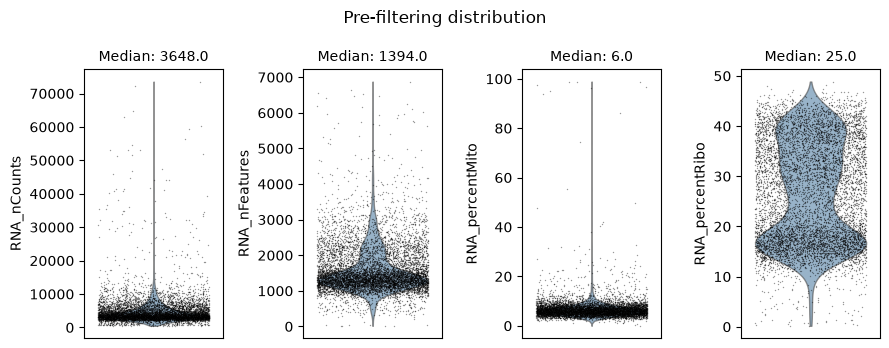

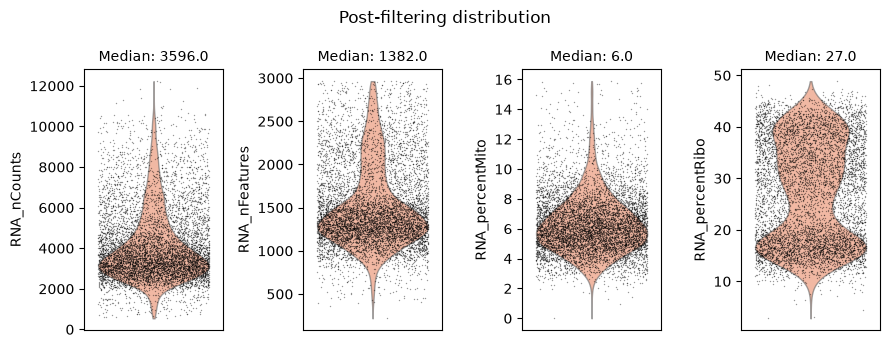

time: 2.11 s (started: 2026-06-28 23:00:03 +02:00)


In [11]:
ds.auto_filter_cells()

INFO: Calculating summary statistics


(RNA) Computing feature stats:   0%|                                                                          …

INFO: Calculating HVGs


INFO: 997 genes marked as HVGs


/home/parashar/scarf/scarf/plots.py:394: RuntimeWarning: divide by zero encountered in log2
  nzm = np.log2(nzm)
/home/parashar/scarf/scarf/plots.py:395: RuntimeWarning: divide by zero encountered in log2
  fv = np.log2(fv)


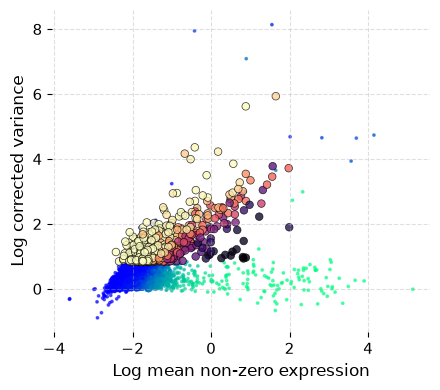

INFO: make_graph step 1/7: normalize expression matrix (computing)


Writing data to normed__I__hvgs/data:   0%|                                                                   …

INFO: make_graph step 1/7: normalize expression matrix finished in 2.7s (computing)


INFO: make_graph step 2/7: normalization statistics (computing)


Calculating mean and std. dev. of norm. data:   0%|                                                           …

...

INFO: make_graph step 7/7: finalize graph metadata (computing)


INFO: make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)


INFO: make_graph finished in 14.2s (7/7 steps, 14.1s in logged steps)


Training UMAP:   0%|                                                                                          …

time: 27.8 s (started: 2026-06-28 23:00:05 +02:00)


In [12]:
ds.mark_hvgs(
    min_cells=20,
    top_n=1000,
    min_mean=-3,
    max_mean=2,
    max_var=6
)

ds.make_graph(
    feat_key='hvgs',
    k=21,
    dims=15,
    n_centroids=100
)

ds.run_umap(
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True
)

ds.run_leiden_clustering(resolution=1)

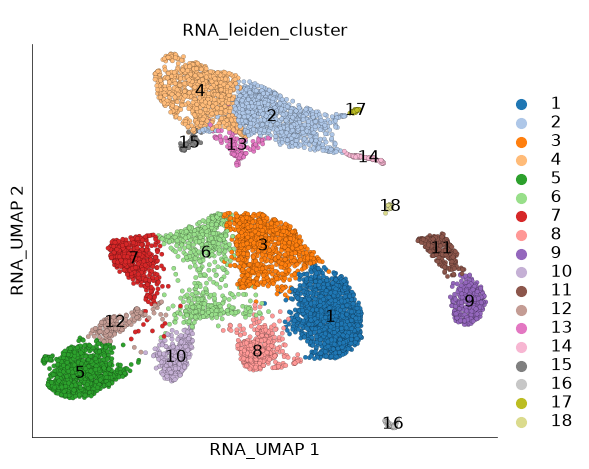

time: 351 ms (started: 2026-06-28 23:00:32 +02:00)


In [13]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by='RNA_leiden_cluster',
    cmap='tab20'
)

In [14]:
ds.ADT.feats.head(n=ds.ADT.feats.N)

,I,ids,names,nCells,dropOuts
0,True,CD3,CD3_TotalSeqB,7864,1
1,True,CD4,CD4_TotalSeqB,7864,1
2,True,CD8a,CD8a_TotalSeqB,7863,2
3,True,CD14,CD14_TotalSeqB,7864,1
4,True,CD15,CD15_TotalSeqB,7864,1
5,True,CD16,CD16_TotalSeqB,7864,1
6,True,CD56,CD56_TotalSeqB,7864,1
7,True,CD19,CD19_TotalSeqB,7702,163
8,True,CD25,CD25_TotalSeqB,7861,4
9,True,CD45RA,CD45RA_TotalSeqB,7864,1


time: 44.9 ms (started: 2026-06-28 23:00:32 +02:00)


In [15]:
adt_names = ds.ADT.feats.to_pandas_dataframe(['names'])['names']
adt_names

0               CD3_TotalSeqB
1               CD4_TotalSeqB
2              CD8a_TotalSeqB
3              CD14_TotalSeqB
4              CD15_TotalSeqB
5              CD16_TotalSeqB
6              CD56_TotalSeqB
7              CD19_TotalSeqB
8              CD25_TotalSeqB
9            CD45RA_TotalSeqB
10           CD45RO_TotalSeqB
11             PD-1_TotalSeqB
12            TIGIT_TotalSeqB
13            CD127_TotalSeqB
14    IgG2a_control_TotalSeqB
15     IgG1_control_TotalSeqB
16    IgG2b_control_TotalSeqB
Name: names, dtype: object

time: 15.1 ms (started: 2026-06-28 23:00:32 +02:00)


In [16]:
is_control = adt_names.str.contains('control').values
is_control

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True,  True,  True])

time: 1.81 ms (started: 2026-06-28 23:00:32 +02:00)


In [17]:
ds.ADT.feats.update_key(~is_control, 'I')
ds.ADT.feats.head(n=ds.ADT.feats.N)

,I,ids,names,dropOuts,nCells
0,True,CD3,CD3_TotalSeqB,1,7864
1,True,CD4,CD4_TotalSeqB,1,7864
2,True,CD8a,CD8a_TotalSeqB,2,7863
3,True,CD14,CD14_TotalSeqB,1,7864
4,True,CD15,CD15_TotalSeqB,1,7864
5,True,CD16,CD16_TotalSeqB,1,7864
6,True,CD56,CD56_TotalSeqB,1,7864
7,True,CD19,CD19_TotalSeqB,163,7702
8,True,CD25,CD25_TotalSeqB,4,7861
9,True,CD45RA,CD45RA_TotalSeqB,1,7864


time: 43.5 ms (started: 2026-06-28 23:00:32 +02:00)


In [18]:
print (ds.ADT)
print (ds.ADT.normMethod.__name__)

ADTassay ADT with 14(17) features
norm_clr
time: 5.89 ms (started: 2026-06-28 23:00:32 +02:00)


In [19]:
ds.make_graph(
    from_assay='ADT',
    feat_key='I', 
    k=21,
    dims=0,
    n_centroids=100
)

INFO: make_graph step 1/7: normalize expression matrix (computing)


Writing data to normed__I__I/data:   0%|                                                                      …

INFO: make_graph step 1/7: normalize expression matrix finished in 0.1s (computing)


INFO: make_graph step 2/7: normalization statistics (computing)


Calculating mean and std. dev. of norm. data:   0%|                                                           …

...

INFO: ANN recall: 99.99%


INFO: make_graph step 7/7: finalize graph metadata (computing)


INFO: make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)


INFO: make_graph finished in 0.7s (7/7 steps, 0.7s in logged steps)


time: 696 ms (started: 2026-06-28 23:00:32 +02:00)


In [20]:
ds.run_umap(
    from_assay='ADT',
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True
)

ds.run_leiden_clustering(
    from_assay='ADT',
    resolution=1
)

Training UMAP:   0%|                                                                                          …

time: 3.71 s (started: 2026-06-28 23:00:33 +02:00)


In [21]:
ds.cells.head()

,I,ids,names,RNA_percentMito,RNA_nCounts,ADT_nFeatures,ADT_UMAP1,ADT_nCounts,ADT_UMAP2,RNA_percentRibo,RNA_nFeatures,ADT_leiden_cluster,RNA_leiden_cluster,RNA_UMAP1,RNA_UMAP2
0,True,AAACCCAAGATTGTGA-1,AAACCCAAGATTGTGA-1,8.668831,6160.0,17.0,-33.554104,981.0,-14.124826,15.259740,2194.0,5,4,-10.716264,32.870102
1,True,AAACCCACATCGGTTA-1,AAACCCACATCGGTTA-1,6.316103,6713.0,17.0,-20.079329,1475.0,-15.724671,19.037688,2093.0,13,4,-11.513350,30.525803
2,True,AAACCCAGTACCGCGT-1,AAACCCAGTACCGCGT-1,8.056090,3637.0,17.0,-25.399221,7149.0,-18.809284,16.002200,1518.0,5,2,0.310531,27.043886
3,True,AAACCCAGTATCGAAA-1,AAACCCAGTATCGAAA-1,9.003215,1244.0,17.0,22.650122,6831.0,-23.877964,18.729904,737.0,3,5,-27.187864,-23.271074
4,True,AAACCCAGTCGTCATA-1,AAACCCAGTCGTCATA-1,6.204519,2611.0,17.0,23.334393,6839.0,-21.521223,16.353887,1240.0,3,5,-33.235912,-19.325687


time: 171 ms (started: 2026-06-28 23:00:37 +02:00)


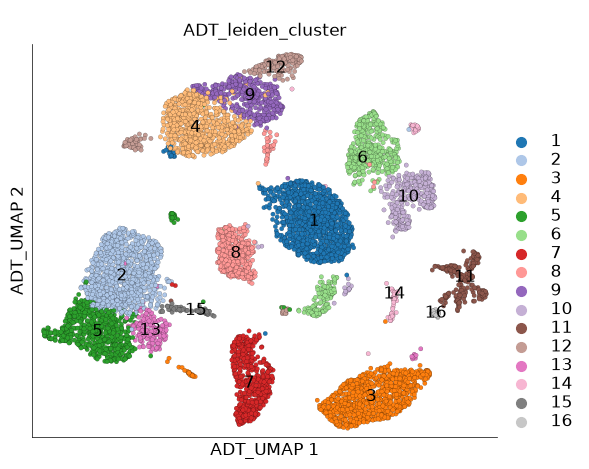

time: 370 ms (started: 2026-06-28 23:00:37 +02:00)


In [22]:
ds.plot_layout(
    layout_key='ADT_UMAP',
    color_by='ADT_leiden_cluster',
    cmap='tab20'
)

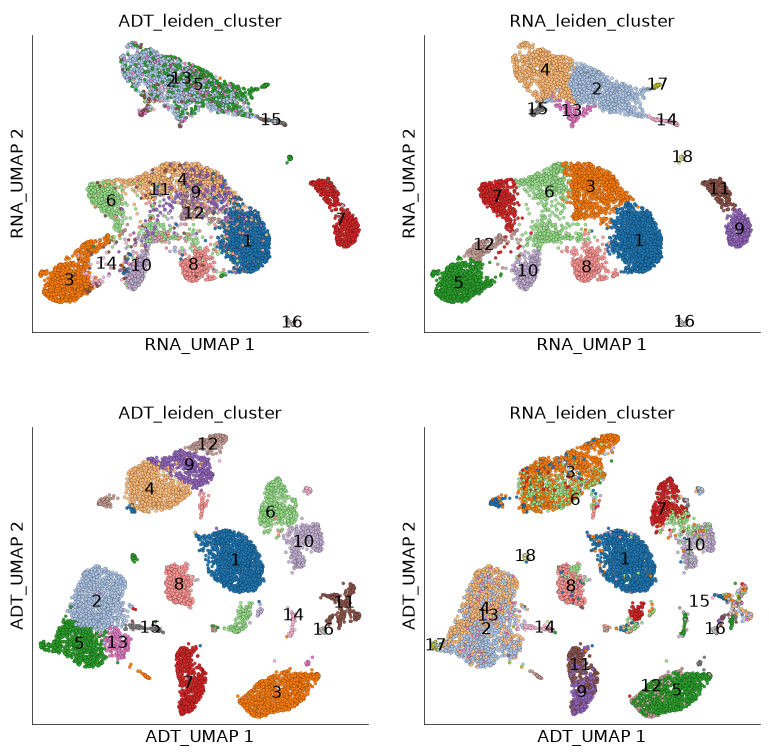

time: 799 ms (started: 2026-06-28 23:00:37 +02:00)


In [23]:
# UMAP on RNA and coloured with clusters calculated on ADT
ds.plot_layout(
    layout_key=['RNA_UMAP', 'ADT_UMAP'],
    color_by=['ADT_leiden_cluster', 'RNA_leiden_cluster'],
    cmap='tab20',
    width=4,
    height=4, 
    n_columns=2,
    point_size=5,
    legend_onside=False
)

In [24]:
import pandas as pd

df = pd.crosstab(
    ds.cells.fetch('RNA_leiden_cluster'),
    ds.cells.fetch('ADT_leiden_cluster')
)
df

col_0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
row_0,,,,,,,,,,,,,,,,
1,1036,0,0,36,3,16,0,31,28,2,17,54,0,0,0,0
2,0,360,1,0,384,3,1,0,3,0,26,1,81,17,5,0
3,33,0,0,367,1,11,1,8,262,15,22,157,0,0,0,0
4,0,566,0,2,175,2,1,0,2,2,33,1,60,7,0,0
5,0,0,732,0,0,0,0,0,1,1,32,0,0,36,1,0
6,4,0,0,277,0,97,0,49,66,64,24,7,0,2,0,0
7,0,0,1,26,0,406,0,6,2,4,14,0,0,2,0,0
8,6,3,0,0,4,24,0,345,1,6,4,4,1,0,0,0
9,0,0,0,0,0,0,315,0,0,0,8,0,0,0,0,0


time: 77.5 ms (started: 2026-06-28 23:00:38 +02:00)


In [25]:
(100 * df.max()/df.sum()).sort_values(ascending=False)

col_0
16    96.666667
1     94.698355
15    86.956522
3     83.466363
8     77.008929
6     70.000000
10    69.552239
9     69.129288
12    67.672414
5     60.282575
7     60.229446
2     56.998993
4     51.617440
13    50.625000
14    45.569620
11    13.095238
dtype: float64

time: 4.87 ms (started: 2026-06-28 23:00:38 +02:00)


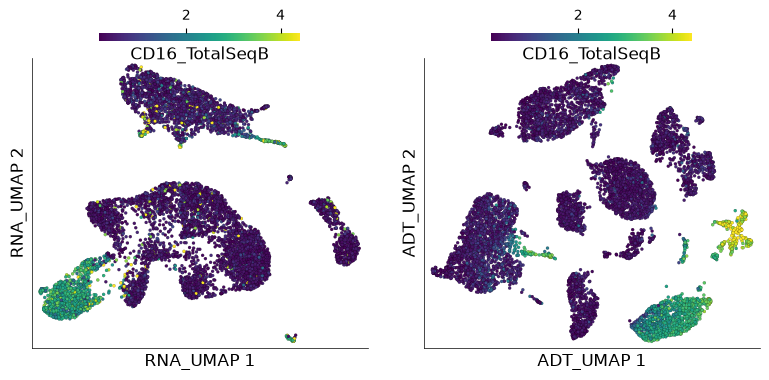

time: 586 ms (started: 2026-06-28 23:00:38 +02:00)


In [26]:
ds.plot_layout(
    layout_key=['RNA_UMAP', 'ADT_UMAP'],
    color_by='CD16_TotalSeqB',
    from_assay='ADT',
    width=4,
    height=4,
    n_columns=2,
    point_size=5
)

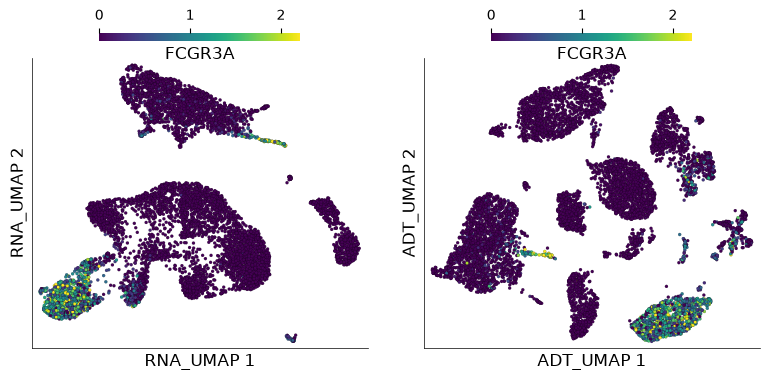

time: 744 ms (started: 2026-06-28 23:00:39 +02:00)


In [27]:
ds.plot_layout(
    layout_key=['RNA_UMAP', 'ADT_UMAP'],
    color_by='FCGR3A',
    from_assay='RNA',
    width=4,
    height=4,
    n_columns=2,
    point_size=5
)

In [28]:
ds.integrate_assays(
    assays=['RNA', 'ADT'],
    label='RNA+ADT'
)

Identifying SNNs in graphs:   0%|                                                                             …

Merging graph edges:   0%|                                                                                    …

time: 2.53 s (started: 2026-06-28 23:00:40 +02:00)


In [29]:
ds.run_umap(
    integrated_graph='RNA+ADT',
    n_epochs=500,
    spread=5,
    min_dist=0.5,
    parallel=True
)

ds.run_leiden_clustering(
    integrated_graph='RNA+ADT',
    resolution=1.75
)

Training UMAP:   0%|                                                                                          …

time: 8.43 s (started: 2026-06-28 23:00:42 +02:00)


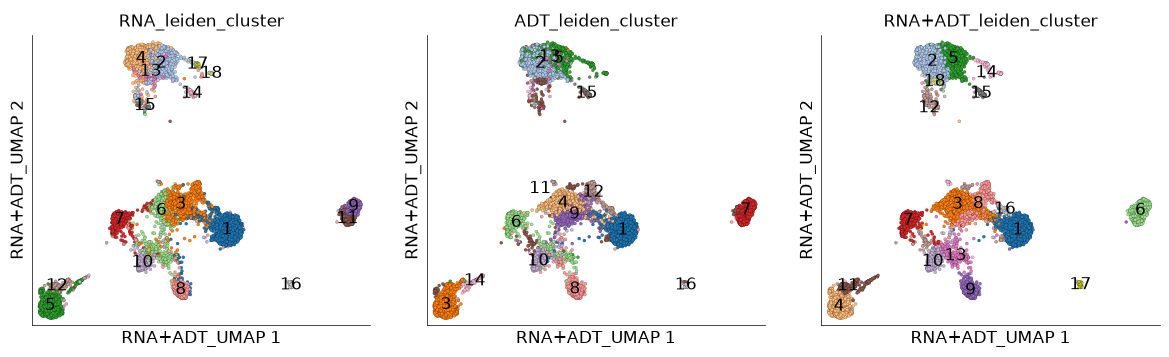

time: 598 ms (started: 2026-06-28 23:00:51 +02:00)


In [30]:
ds.plot_layout(
    layout_key=['RNA+ADT_UMAP'],
    color_by=['RNA_leiden_cluster',
              'ADT_leiden_cluster',
              'RNA+ADT_leiden_cluster'],
    cmap='tab20',
    legend_onside=False,
    point_size=5,
    width=4,
    height=4,
    n_columns=3
)

In [31]:
ds.cells.columns

['I',
 'ids',
 'names',
 'RNA_percentMito',
 'ADT_nCounts',
 'ADT_nFeatures',
 'ADT_UMAP2',
 'RNA_nFeatures',
 'ADT_UMAP1',
 'RNA_percentRibo',
 'RNA+ADT_UMAP1',
 'RNA_leiden_cluster',
 'RNA_UMAP2',
 'RNA+ADT_leiden_cluster',
 'ADT_leiden_cluster',
 'RNA+ADT_UMAP2',
 'RNA_UMAP1',
 'RNA_nCounts']

time: 13.2 ms (started: 2026-06-28 23:00:51 +02:00)


In [32]:
ds.integrate_assays(
    assays=['RNA', 'ADT'],
    label='RNA+ADT_wnn',
    method='wnn'
)

ds.run_umap(
    integrated_graph='RNA+ADT_wnn',
    n_epochs=500,
    spread=5,
    min_dist=0.5,
    parallel=True
)

ds.run_leiden_clustering(
    integrated_graph='RNA+ADT_wnn',
    resolution=1.75
)

INFO: make_graph step 1/7: normalize expression matrix (reusing cached)


INFO: Using existing normalized data with cell key I and feat key I__hvgs


INFO: make_graph step 1/7: normalize expression matrix finished in 0.1s (reusing cached)


INFO: make_graph step 2/7: normalization statistics (reusing cached)


INFO: make_graph step 2/7: normalization statistics finished in 0.0s (reusing cached)


...

(ADT) Predicting cross modality profile:   0%|                                                                …

/home/parashar/scarf/scarf/knn_utils.py:521: RuntimeWarning: overflow encountered in exp
  wr = np.exp(sr) / (np.exp(sr) + np.exp(sp))
/home/parashar/scarf/scarf/knn_utils.py:522: RuntimeWarning: overflow encountered in exp
  wp = np.exp(sp) / (np.exp(sr) + np.exp(sp))
/home/parashar/scarf/scarf/knn_utils.py:522: RuntimeWarning: invalid value encountered in divide
  wp = np.exp(sp) / (np.exp(sr) + np.exp(sp))


Building WNN graph:   0%|                                                                                     …

Training UMAP:   0%|                                                                                          …

time: 7.29 s (started: 2026-06-28 23:00:51 +02:00)


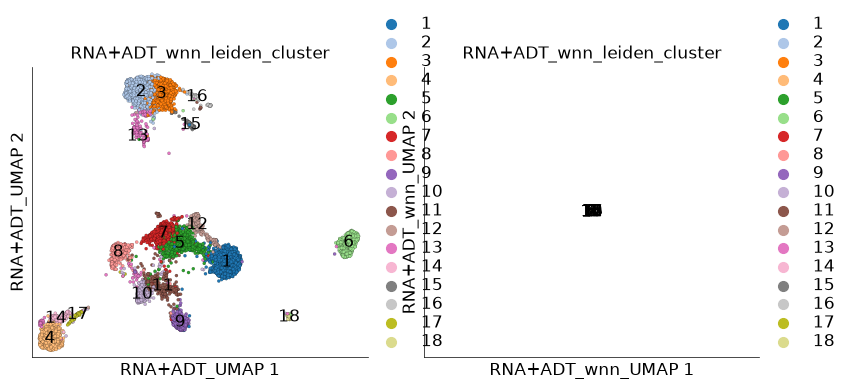

time: 713 ms (started: 2026-06-28 23:00:58 +02:00)


In [33]:
ds.plot_layout(
    layout_key=['RNA+ADT_UMAP', 'RNA+ADT_wnn_UMAP'],
    color_by='RNA+ADT_wnn_leiden_cluster',
    cmap='tab20',
    point_size=5,
    width=4,
    height=4,
    n_columns=2
)